Prueba

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
pip install darts

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.8/165.8 kB 11.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 934.2/934.2 kB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 56.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 815.2/815.2 kB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.7/314.7 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.4/271.4 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 890.5/890.5 kB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.3 MB/s eta 0:00:

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from darts.models import TFTModel
from darts import TimeSeries
import torch
import pytorch_lightning as pl
#from darts.datasets import AirPassengersDataset

/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from keras.models import Sequential
from keras.layers import Dense, Dropout, GRU, InputLayer, Flatten
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
import os
np.random.seed(42)


LEER DATASET

In [5]:
import pandas as pd

datos = pd.read_csv("/content/drive/MyDrive/transformers/datosNarmax/1_consumption_tft", delimiter=",")
datos = datos.drop(columns=['Unnamed: 0'])


datos['date'] = pd.to_datetime(datos['date'])

# Se establece la columna date como index
datos.set_index('date', inplace=True)


In [6]:
datos.head()

,temp,zone1,zone2,zone3,hour,error
date,,,,,,
2017-01-01 00:00:00,-2.051356,0.151445,-0.851669,0.033500,-1.660858,NaN
2017-01-01 00:10:00,-2.074813,-0.433079,-0.211097,0.016502,-1.660858,NaN
2017-01-01 00:20:00,-2.091152,-0.527709,-0.283791,-0.055068,-1.660858,NaN
2017-01-01 00:30:00,-2.122213,-0.651648,-0.411186,-0.174054,-1.660858,NaN
2017-01-01 00:40:00,-2.154568,-0.774750,-0.507632,-0.244729,-1.660858,NaN


In [7]:
#Se verifica que el index está en formato de dato "datetime64"
print("El index del dataframe input es un tipo de dato: ", datos.index.dtype)


El index del dataframe input es un tipo de dato:  datetime64[ns]


In [8]:
datos['error'] = datos['error'].fillna(0)

In [9]:
datosNormalizados = datos

In [10]:
pasados = 12

In [11]:
serie = TimeSeries.from_dataframe(datosNormalizados)

print(serie)

<TimeSeries (DataArray) (date: 52416, component: 6, sample: 1)> Size: 3MB
array([[[-2.05135573],
        [ 0.15144479],
        [-0.85166941],
        [ 0.03349964],
        [-1.66085756],
        [ 0.        ]],

       [[-2.07481311],
        [-0.43307937],
        [-0.21109699],
        [ 0.01650173],
        [-1.66085756],
        [ 0.        ]],

       [[-2.0911524 ],
        [-0.52770864],
        [-0.28379117],
        [-0.05506842],
        [-1.66085756],
        [ 0.        ]],
...
       [[-1.99619043],
        [-0.46392619],
        [ 0.9536657 ],
        [-0.96188815],
        [ 1.66304358],
        [-0.05360063]],

       [[-2.01916249],
        [-0.551129  ],
        [ 0.8381378 ],
        [-1.0073498 ],
        [ 1.66304358],
        [-0.03380482]],

       [[-2.04795845],
        [-0.63497785],
        [ 0.71243763],
        [-1.03320054],
        [ 1.66304358],
        [-0.06657589]]])
Coordinates:
  * date       (date) datetime64[ns] 419kB 2017-01-01 ... 2017-12-30T2

In [12]:
Y = serie["zone1"]
X = serie.drop_columns("zone1")


trainX, testX = X.split_after(0.7)
testX, valX = testX.split_after(0.66)
testX, testX2 = testX.split_after(0.6)

print(len(trainX))
print(len(testX))
print(len(testX2))
print(len(valX))

36691
6227
4151
5347


36691
6227
4151
5347


<Axes: xlabel='date'>

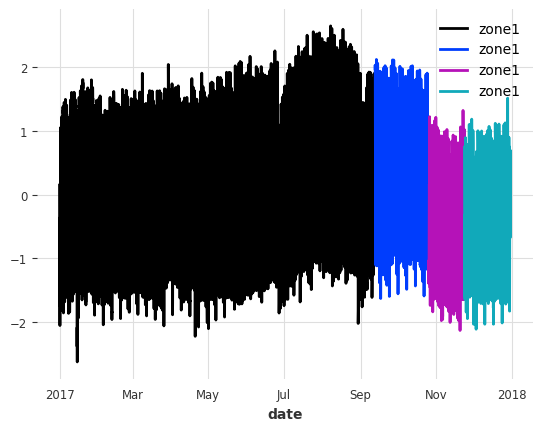

In [13]:
trainY, testY = Y.split_after(0.7)
testY, valY = testY.split_after(0.66)
testY, testY2 = testY.split_after(0.6)


print(len(trainY))
print(len(testY))
print(len(testY2))
print(len(valY))

trainY.plot()
testY.plot()
testY2.plot()
valY.plot()

In [14]:
space = {
    'hidden_size': hp.choice('hidden_size',[16, 32, 64, 128, 256]),
    'hidden_continuous_size': hp.choice('hidden_continuous_size',[8,16,32,64,128]),
    'num_attention_heads': hp.choice('num_attention_heads', [2,4,8]),
    'dropout': hp.quniform('dropout', 0, 0.5, 0.1),  # Dropout para regularización
    'batch_size': hp.choice('batch_size',[2 ** i for i in range(3, 9)]),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.000001), np.log(0.01)),
    'lstm_layers': hp.quniform('lstm_layers', 1, 4, 1)
}


In [15]:
futuros=0

In [ ]:
def objective(params):
    print(params)
    early_stopper = pl.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    min_delta=0,
    mode='min',
    verbose = True
    )


    my_model = TFTModel(
        input_chunk_length=pasados,
        output_chunk_length=1,
        hidden_size=int(params["hidden_size"]),
        dropout=float(params["dropout"]),
        batch_size=int(params["batch_size"]),
        n_epochs=128,
        optimizer_kwargs={"lr": float(params["learning_rate"])},
        random_state=42,
        add_relative_index= True,
        loss_fn=torch.nn.MSELoss(),
        likelihood=None,
        output_chunk_shift = futuros,
        save_checkpoints = True,
        use_static_covariates = False,
        lstm_layers = int(params["lstm_layers"]),
        hidden_continuous_size = int(params["hidden_continuous_size"]),
        num_attention_heads = int(params["num_attention_heads"]),
        pl_trainer_kwargs= {"callbacks": [early_stopper],
                            "accelerator": "gpu",  
                            "devices": "auto"}
    )
    my_model.fit(
        series=testY,
        val_series=testY2,
        past_covariates=testX,
        val_past_covariates=testX2,
        verbose=True
    )
    my_model = TFTModel.load_from_checkpoint(model_name=my_model.model_name, best=True)

    # Crear todas las ventanas de 12 pasos
    windowed_target_series = [valY[i:i + 12] for i in range(0, len(valY) - 12)]
    windowed_covariates_series = [valX[i:i + 12] for i in range(0, len(valX) - 12)]
    batch_size = 32
    all_predictions = []
    # Dividimos las ventanas en lotes (batches)
    for i in range(0, len(windowed_target_series), batch_size):
        batch_target_windows = windowed_target_series[i:i + batch_size]
        batch_covariates_windows = windowed_covariates_series[i:i + batch_size]

        # Hacer la predicción para este lote de ventanas
        predictions = my_model.predict(
            n=1,  # Predecir solo un valor futuro para cada ventana
            series=batch_target_windows,  # Ventanas de la serie target
            past_covariates=batch_covariates_windows,  # Ventanas de las covariantes
            batch_size=batch_size,  # Tamaño del batch
            verbose=False
        )
        for pred in predictions:
            all_predictions.extend(pred.values())

    predictions = np.array(all_predictions)


    real = np.array(valY[pasados+futuros:].values())
    if len(real) > len(predictions):
        real = real[:len(predictions)]
    else:
        predictions = predictions[:len(real)]

    loss = mean_squared_error(real, predictions)
    return {'loss': loss, 'status': STATUS_OK}

In [17]:
import logging
log = logging.getLogger("pytorch_lightning")
log.propagate = False
log.setLevel(logging.ERROR)

In [18]:
import pytorch_lightning as pl

# Fijar la semilla para la reproducibilidad
pl.seed_everything(42)

INFO:lightning_fabric.utilities.seed:Seed set to 42


42

In [19]:
trials = Trials()
best = fmin(objective, space, algo=tpe.suggest, max_evals=12, trials=trials, rstate=np.random.default_rng(42))

print(best)

{'batch_size': 64, 'dropout': 0.4, 'hidden_continuous_size': 16, 'hidden_size': 256, 'learning_rate': 0.003433258483724734, 'lstm_layers': 3.0, 'num_attention_heads': 2}
  0%|          | 0/12 [00:00<?, ?trial/s, best loss=?]

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.10/dist-packages/darts/models/forecasting/torch_forecasting_model.py:1842: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model: TorchForecastingModel 

100%|██████████| 12/12 [2:34:36<00:00, 773.07s/trial, best loss: 0.006518336282897891] 
{'batch_size': 2, 'dropout': 0.1, 'hidden_continuous_size': 2, 'hidden_size': 0, 'learning_rate': 0.0009820714637468857, 'lstm_layers': 3.0, 'num_attention_heads': 1}


In [20]:
print(best)

{'batch_size': 2, 'dropout': 0.1, 'hidden_continuous_size': 2, 'hidden_size': 0, 'learning_rate': 0.0009820714637468857, 'lstm_layers': 3.0, 'num_attention_heads': 1}
